In [1]:
import EFC_learningfMRI.globals as gl
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import EFC_learningfMRI.vis as vis
import EFC_learningfMRI.force as force
import EFC_learningfMRI.util as util

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


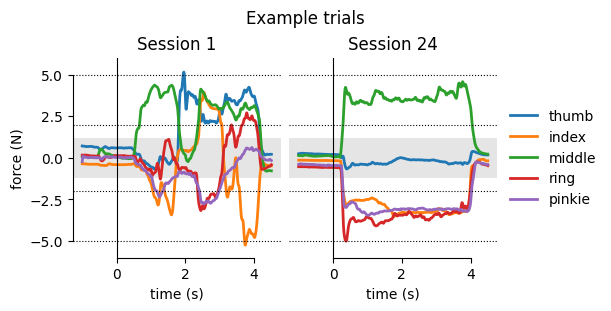

In [2]:
sn = 101
n_block = [1, 1]
sessions  = [1, 24]
n_trial = [12, 15]  # chord 92122
trained = util.get_trained_and_untrained(sn)
ch_idx = np.array(gl.diffCols)

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(6, 3), constrained_layout=True,)

vis.plot_example_trial(fig, axs, sessions, sn=101, n_block=n_block, n_trial=[12, 15])

plt.show()

In [16]:
for s, sess in enumerate(sessions):
    filename = os.path.join(gl.baseDir, 'behavioural', f'day{sess}', f'efc4_{sn}_{n_block[s]:02d}.mov')
    mov = force.load_mov(filename)[n_trial[s]]
    mov = mov[(mov[:, 1] == gl.wait_exec) | (mov[:, 1] == gl.wait_exec - 1) | (mov[:, 1] == gl.wait_exec + 1)]
    F = mov[:, ch_idx] * gl.fGain
    dat = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', f'day{sess}', f'efc4_{sn}.dat'), sep='\t')
    dat_row = dat[(dat.TN == n_trial[s]) & (dat.BN == n_block[s])].reset_index()
    trial_row = pd.Series(force._trial_row(F, dat_row, trained=trained))
    print(f'Session {sess}, chordID: {trial_row["chordID"]}')
    print('Absolute force:')
    print(trial_row[['thumb_abs', 'index_abs', 'middle_abs', 'ring_abs', 'pinkie_abs']])
    print('Absolute force derivative:')
    print(trial_row[['thumb_der', 'index_der', 'middle_der', 'ring_der', 'pinkie_der']])
    print('\n')

Session 1, chordID: 92122
Absolute force:
thumb_abs     1.657998
index_abs     0.651838
middle_abs    2.101271
ring_abs      0.148335
pinkie_abs    0.814068
dtype: object
Absolute force derivative:
thumb_der     4.352746
index_der     6.375534
middle_der    4.646426
ring_der      4.526575
pinkie_der    2.207648
dtype: object


Session 24, chordID: 92122
Absolute force:
thumb_abs     0.085238
index_abs     2.062002
middle_abs    2.743202
ring_abs      2.091102
pinkie_abs    2.141859
dtype: object
Absolute force derivative:
thumb_der     0.786741
index_der     1.760039
middle_der    3.044223
ring_der      2.790929
pinkie_der    1.724984
dtype: object


